# MOFODRONI: Monitoring and forecasting agricultural drought for rainfed rice in Nigeria, using multi-source data.

Welcome to the Jupyter Notebook for processing multi-source satellite data in order to facilitate drought monitoring for rice-growing regions of Nigeria. Before running this Notebook, ensure the kernel is set to 'MOFODRONI'.

## Importing packages and defining variables

In this first section, we will import all required packages (including custom scripts written for running VICI, clustering, etc.). Ideally this section should run automatically without errors. 

Important variables:  
`run_clipping` : setting to *True* will crop yearly NDVI data to predefined bounding box/extent (in our case, borders of Nigeria)  
`run_invalid_masking` : setting to *True* will create a mask file of all invalid pixels to remove them from later processing  
`run_clustering` : setting to *True* will run KMeans clustering to create clusters of similar NDVI observation regions  
`run_stats` : setting to *True* will run extraction of statistics from NDVI clusters  

In [1]:
#Importing the required packages
import glob
import os
from pathlib import Path
from osgeo import gdal
import numpy as np
import rasterio
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import math
import importlib
import seaborn as sns
import xarray as xr
from matplotlib.patches import Rectangle
import matplotlib.dates as mdates

import prepare_country_VICI
import calculate_VICI
import crop_raster
import stack_tif
import kmeans
import cluster_stats
import seasons
import adj_factors

print("All packages imported successfully.")

All packages imported successfully.


In [2]:
def flatten(xss):
    return [x for xs in xss for x in xs]

def create_drought_limits(year,drought_months):
    drought_limits = {'start_drought': [f'{year}-{drought_months[0]}-01'],
                      'end_drought': [f'{year}-{f'{int(drought_months[-1])+1:02d}'}-01']}
    drought_limits = pd.DataFrame(drought_limits)
    for col in drought_limits.columns:
        drought_limits[col] = pd.to_datetime(drought_limits[col])
    return drought_limits

    
def make_dirs(main_dir,foldername):
    output_dir = os.path.join(main_dir,foldername)
    os.makedirs(output_dir,exist_ok = True)
    savgol_folder = os.path.join(main_dir,"SM")
    cropped_folder = os.path.join(output_dir,"cropped_country_swia")
    os.makedirs(cropped_folder,exist_ok = True)
    invalid_pixel_folder = os.path.join(output_dir,"invalid_pixel_swia")
    os.makedirs(invalid_pixel_folder,exist_ok=True)
    analysis_folder = os.path.join(output_dir,"analysis_swia")
    os.makedirs(analysis_folder, exist_ok = True)
    images_folder = os.path.join(output_dir,"images")
    os.makedirs(images_folder, exist_ok = True)

    return output_dir, savgol_folder, cropped_folder, invalid_pixel_folder, analysis_folder, images_folder
    
def create_zones(cluster_folder,output_dir,invalid_pixel_folder,num_zones,run_clustering,flag_harmonics):
    
    output_CPSZ = os.path.join(cluster_folder,f"CPSZ_{num_zones}zones.tif")

    #Create stack of rasters
    stack_folder = os.path.join(output_dir,"stacks")
    output_cube = os.path.join(stack_folder,"cube_to_cluster_swia.img")
    os.makedirs(stack_folder,exist_ok=True)
        
    cropped_files = sorted(glob.glob(os.path.join(cropped_folder,"*","*"+country+".tif")))
    invalid_pix_files = sorted(glob.glob(os.path.join(invalid_pixel_folder,"*","*"+country+".tif")))
    cropped_stack = os.path.join(stack_folder,"cropped_SWI_stack.tif")
    invalid_stack = os.path.join(stack_folder,"invalid_pixel_stack_swia.tif")
    
    if run_clustering:
        #scale flag used to scale NDVI from 0-250 to 0-1, not needed for invalid pixels 
        if not os.path.isfile(cropped_stack):
            stack_tif.merge_tifs_to_multiband(cropped_files,cropped_stack)
        if not os.path.isfile(invalid_stack):
            stack_tif.merge_tifs_to_multiband(invalid_pix_files,invalid_stack)
        
        #Create clusters - when rerunning, make sure that the cube is removed:
        #if os.path.isfile(output_cube):
        #    os.remove(output_cube)
            
        if not os.path.isfile(output_CPSZ):
            kmeans.cluster_KMeans(cropped_stack,invalid_stack,output_cube,output_CPSZ,num_zones,flag_harmonics)
        else:
            print(f'{output_CPSZ} already exists, skipping')
        print("KMeans clustering finished")    
    
    return output_CPSZ, invalid_stack, stack_folder
    
def define_seasons(output_CPSZ,stack_folder,stats_folder,cluster_folder,num_zones,flag_harmonics):
    #Define Seasons
    #Create median stack
    median_stack = os.path.join(stack_folder,f"median_stack_harm{flag_harmonics}_{num_zones}zones.tif")
    median_files = sorted(glob.glob(os.path.join(stats_folder,"p50","*.tif")))
        
    stack_tif.merge_tifs_to_multiband(median_files,median_stack)
        
    with rasterio.open(output_CPSZ) as src:
        cps = src.read()
    zones = np.unique(cps)
        
    seasons_file = os.path.join(stats_folder,"seasons.csv")
        
    seasons.get_seasons(median_stack,output_CPSZ,seasons_file)
        
    seasons_folder = os.path.join(cluster_folder,"season_masks")
    os.makedirs(seasons_folder,exist_ok=True)
        
    seasons.season_mask(output_CPSZ,seasons_file,seasons_folder)

    
def run_VICI_calc(cluster_stats,cluster_folder,output_dir,bbox,upper_threshold):
    import importlib
    import calculate_VICI
    importlib.reload(calculate_VICI)
    
    VICI_folder = os.path.join(cluster_folder,"VICI")
    os.makedirs(VICI_folder,exist_ok=True)
    dekads = cluster_stats.get_dekads()
    years = [2024]#[y for y in range(1999,2025)]

    lower_threshold = "p05"

    onlyCropland = True
    processMasks=True

    for year in years:
        for dekad in dekads:
            date = f'{year}{dekad}'

            calculate_VICI.calculate_VICI(date,lower_threshold,upper_threshold,VICI_folder,output_dir,bbox,onlyCropland,processMasks)
    
    

Important variables:  
`country` : default is "Nigeria", this will only be relevant for saving file names  
`year` : year for running the drought monitoring calculations, first try for 2021

In [3]:
#Determine variables
country = "Nigeria"
year = 2024

run_clipping = False
run_cropland = True
run_invalid_masking = False
run_clustering = True
run_stats = True

main_dir = Path(os.getcwd()).parent
output_dir, savgol_folder, cropped_folder, invalid_pixel_folder, analysis_folder, out_images = make_dirs(main_dir,'Output')

nigeria_shp = os.path.join(main_dir, 'shapefiles','nigeria_country.shp')
nigeria_vector = gpd.read_file(nigeria_shp)['geometry']

#BoundingBox - Set values to the desired bbox
minX = 2.6 #2.6
maxX = 14.5 #14.5
minY = 4.2 #4.2
maxY = 13.8 #13.8
bbox = [minX,minY,maxX,maxY]
print(f'Location is {country}, year is {year}')
print(output_dir)

Location is Nigeria, year is 2024
/home/eoafrica/shared/MOFODRONI/Output


## Clipping NDVI files

NDVI composites covering the whole of Africa need to be clipped to the boundaries of Nigeria, using the shapefile read as 'nigeria_vector'. If clipping is activated, we will loop through all of the NDVI files and crop them, saving them in the defined folder ./Output/cropped_country  
No additional variables need to be defined here.

In [4]:

if run_clipping:
    #Cropping the NDVI data to the bbox
    error_list = []
    #Create for-loop here to also loop over years 1999-2024
    for year in range(2007,2025):

        print(f'Processing year {year}')
        savgol_y = os.path.join(savgol_folder,str(year))
        output_y = os.path.join(output_dir,"cropped_swia",str(year))
        country_y = os.path.join(output_dir,"cropped_country_swia",str(year))
        os.makedirs(country_y,exist_ok=True)
        os.makedirs(output_y,exist_ok=True)

        savgol_files = glob.glob(os.path.join(savgol_y,"*.tif"))

        for file in savgol_files:
            try:
                #print(f'Processing {file}')
                input_file = file
                output_file = os.path.join(output_y,Path(file).stem[6:20]+".tif").replace(".tif",f"_{country}.tif")
                country_file = os.path.join(country_y,Path(file).stem[6:20]+".tif").replace(".tif",f"_{country}.tif")
                crop_raster.crop(input_file,output_file,bbox)
                with rasterio.open(output_file) as src:
                    out_image, out_transform = rasterio.mask.mask(src, nigeria_vector, crop=True)
                    out_meta = src.meta
                out_meta.update({"driver": "GTiff",
                     "height": out_image.shape[1],
                     "width": out_image.shape[2],
                     "transform": out_transform})
                with rasterio.open(country_file, "w", **out_meta) as dest:
                    dest.write(out_image)

            except Exception as e:
                print(e)
                error_list.append(file)
                continue
        print(f'Year {year} completed successfully.')
        
    # visualise example of results
    print('Example of clipped SWI below:')
    country_open = rasterio.open(country_file,'r').read(1)
    country_scaled = country_open * 0.004
    plt.imshow(country_scaled,cmap='gray')
    plt.title(f'Nigeria SWI {country_file.split('_')[-2]}')
    plt.colorbar()
    

In [25]:
cropped_folder

'/home/eoafrica/shared/MOFODRONI/Output/cropped_country_swia'

## Invalid Pixel masking

This section creates an invalid pixel mask, which prevents the algorithm from processing those pixels and biasing/skewing the calculations.

In [112]:
#Creating a masking file for invalid pixels.

if run_invalid_masking:

    cropped_files = sorted(glob.glob(os.path.join(cropped_folder,"*","*.tif")))
    for cropped_file in cropped_files:
        path_stem = Path(cropped_file).stem.split('_')
        inv_file_name = path_stem[0]+'_'+path_stem[1][:4]+'-'+path_stem[1][4:6]+'-'+path_stem[1][6:8]+'_'+path_stem[2]

        invalid_file = os.path.join(invalid_pixel_folder,Path(cropped_file).parent.stem,inv_file_name+".tif")
        print(invalid_file)
        with rasterio.open(cropped_file) as src:
            data = src.read()
            profile = src.profile

        invalid = data.copy()
        invalid[np.isnan(invalid)]=255
        invalid = invalid.astype("uint8")

        os.makedirs(Path(invalid_file).parent,exist_ok=True)
        
        profile['nodata']=255
        with rasterio.open(invalid_file, "w", **profile) as dst:
            dst.write(invalid[0,:,:],1)
            
            template_dict = {
            "width":dst.width,
            "height":dst.height,
            "crs":dst.crs,
            "transform":dst.transform,
            "extent":dst.bounds,
            "resolution":dst.res,
            'dtype':profile["dtype"]
            }
        
        
    print("Invalid Pixel Mask is created")

In [113]:
ds = rasterio.open(r'/home/eoafrica/shared/MOFODRONI/Output/stacks/invalid_pixel_stack_swia.tif')
ds.read().shape

(648, 1068, 1325)

## Clustering

The next step conducts KMeans clustering on the cropped NDVI images, stacking them together first. The `num_zones` variable is used to change the total number of clustering zones. Otherwise all other variables can be left untouched. 

In [111]:
flag_harmonics = False
for num_zones in [5,10,20,30,40,50,60,70,80,90,100,110,120]:
    out_folder = os.path.join(output_dir,"analysis_swia",f"{num_zones:02}zones")
    os.makedirs(out_folder,exist_ok=True)
    output_CPSZ, invalid_stack, stack_folder = create_zones(out_folder,output_dir,invalid_pixel_folder,num_zones,run_clustering,flag_harmonics)

Multi-band TIFF saved as: /home/eoafrica/shared/MOFODRONI/Output/stacks/cropped_SWI_stack.tif
Multi-band TIFF saved as: /home/eoafrica/shared/MOFODRONI/Output/stacks/invalid_pixel_stack_swia.tif
/home/eoafrica/shared/MOFODRONI/Output/analysis_swia/05zones/CPSZ_5zones.tif already exists, skipping
KMeans clustering finished
/home/eoafrica/shared/MOFODRONI/Output/analysis_swia/10zones/CPSZ_10zones.tif already exists, skipping
KMeans clustering finished
/home/eoafrica/shared/MOFODRONI/Output/analysis_swia/20zones/CPSZ_20zones.tif already exists, skipping
KMeans clustering finished
/home/eoafrica/shared/MOFODRONI/Output/analysis_swia/30zones/CPSZ_30zones.tif already exists, skipping
KMeans clustering finished
/home/eoafrica/shared/MOFODRONI/Output/analysis_swia/40zones/CPSZ_40zones.tif already exists, skipping
KMeans clustering finished
/home/eoafrica/shared/MOFODRONI/Output/analysis_swia/50zones/CPSZ_50zones.tif already exists, skipping
KMeans clustering finished
/home/eoafrica/shared/MOFO

In [6]:
invalid_stack = r'/home/eoafrica/shared/MOFODRONI/Output/stacks/invalid_pixel_stack_swia.tif'
import shutil

for num_zones in [5]:
    out_folder = os.path.join(output_dir,"analysis_swia",f"{num_zones:02}zones")
    output_CPSZ = os.path.join(out_folder,f"CPSZ_{num_zones}zones.tif")
    print(f'Running for {num_zones} zones')
    
    for u_thresh in range(15,55,5):
        upper_threshold = "p"+str(u_thresh)
        sub_an = "analysis_05_"+str(u_thresh)
        cluster_folder = os.path.join(out_folder,sub_an)
        os.makedirs(cluster_folder,exist_ok=True)
        print(f'Running for {upper_threshold}')
                        
        C_Adj_file = os.path.join(cluster_folder,'C_stack_adj_swia.tif')
        Adjusted_NDVI_file = os.path.join(cluster_folder,'Adj_SWI_stack.tif')
            
        with rasterio.open(output_CPSZ,'r') as src:
            cpsz = src.read()
        zones=np.unique(cpsz)
        print(f'Total {len(zones)} zones.')
            
        print('Running stats.')
        stats_folder = os.path.join(cluster_folder,"cluster_stats_swia")
        os.makedirs(stats_folder,exist_ok=True)
                    
        stats_list = ["lta","std","p05","p10","p15","p20","p25","p50","p75","p90"]
        cluster_stats.cluster_stats(output_CPSZ,invalid_stack,stats_folder,stats_list)
            
        print('Running compute adjustments')
        adj_factors.compute_adjustments(invalid_stack,output_CPSZ,C_Adj_file,cluster_folder)
            
        print('Running compute adjustments')
        adj_factors.apply_correction_factor(invalid_stack, C_Adj_file, Adjusted_NDVI_file)
            
        print('Running percentiles')
        outdir_percentiles = os.path.join(cluster_folder,"percentiles_swia")
        os.makedirs(outdir_percentiles,exist_ok=True)
        percentile_numbers = ['05', str(u_thresh)]
        percentiles, p50_array = adj_factors.compute_percentiles(Adjusted_NDVI_file, output_CPSZ, percentile_numbers, outdir_percentiles)
            
        seasons_file = os.path.join(stats_folder,"seasons.csv")
        seasons_arr = adj_factors.get_seasons(p50_array, zones, seasons_file)
        adj_factors.correct_percentiles_for_seasons(output_CPSZ, seasons_arr,percentiles, percentile_numbers, outdir_percentiles)
            
        all_dates = [val.split('_')[-2] for val in sorted(glob.glob(os.path.join(invalid_pixel_folder,'*','*.tif')))]
        VICI_folder = os.path.join(cluster_folder,"SWIA")
        print(f'out vici folder: {VICI_folder}')
        os.makedirs(VICI_folder,exist_ok=True)
        dekads = cluster_stats.get_dekads()
        years = [y for y in range(2019,2025)]
                    
        lower_threshold,upper_threshold = [f"p{n:02}" for n in percentile_numbers]
        
        for year in years:
            for dekad in dekads:
                date = f'{year}{dekad}'
                calculate_VICI.calculate_SWIA(output_CPSZ,date,lower_threshold,upper_threshold,VICI_folder,output_dir,bbox,all_dates)
                
        os.remove(Adjusted_NDVI_file)
        os.remove(C_Adj_file)
        shutil.rmtree(os.path.join(cluster_folder,'adjustments'))
        shutil.rmtree(os.path.join(cluster_folder,'percentiles_swia'))

Running for 5 zones
Running for p15
Total 5 zones.
Running stats.
No. dekads: 36
No. unique zones: 5
Finished processing all dekads.
Running compute adjustments
Computing NDVI adjustments per CPS zone...
Saving dekadal adjustments
Finished saving zonal adjustments.
Running compute adjustments
Applying zonal adjustment factor to NDVI values...
Running percentiles
Computing dekadal percentiles per CPS zone...
Computing seasons...
Finished computing seasons.
Correcting percentiles for seasons and saving them per dekad and CPS zone...
out vici folder: /home/eoafrica/shared/MOFODRONI/Output/analysis_swia/05zones/analysis_05_15/SWIA
Running for p20
Total 5 zones.
Running stats.
No. dekads: 36
No. unique zones: 5
Finished processing all dekads.
Running compute adjustments
Computing NDVI adjustments per CPS zone...
Saving dekadal adjustments
Finished saving zonal adjustments.
Running compute adjustments
Applying zonal adjustment factor to NDVI values...
Running percentiles
Computing dekadal pe

## Apply models

In [40]:
import geopandas as gpd
import os
import glob
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import rasterio
import math
import seaborn as sns
from osgeo import gdal
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from statsmodels.regression.linear_model import OLS
from statsmodels.iolib.summary2 import summary_col

def rearrange_plotvals(in_plots,year):
    plots = in_plots.copy()
    plots['Drought degree'] = plots['C9']
    plots.drop(plots.loc[plots[f'?INC{year}'] == 'NIL'].index, inplace=True)
    plots[f'change{year}'] = plots[f'?INC{year}'].astype(float)

    plots[f'bin{year}'],bins = pd.qcut(plots[f'change{year}'],q=5,retbins=True,labels=False)
    bin_labels = [str(np.round(bins[0],1)) + ' to ' + str(np.round(bins[1],1)),
        str(np.round(bins[1],1)) + ' to ' + str(np.round(bins[2],1)),
        str(np.round(bins[2],1)) + ' to ' + str(np.round(bins[3],1)),
        str(np.round(bins[3],1)) + ' to ' + str(np.round(bins[4],1)),
        str(np.round(bins[4],1)) + ' to ' + str(np.round(bins[5],1))]

    plots[f'bin{year}'],bins = pd.qcut(plots[f'change{year}'],q=5,retbins=True,labels=bin_labels)
    
    return plots

def flatten(xss):
    return [x for xs in xss for x in xs]

def arrange_dt(dt_str):
    return dt_str[0:4]+'-'+dt_str[4:6]+'-'+dt_str[6:]

def obs_plot(obs_df, out_file):
    ax = obs_df.plot()
    ax.set_ylabel('Num. drought observations')
    ax.set_xlabel('Upper threshold (%)')
    plt.savefig(out_file)

def rework_riceplots(rice_plots):
    rice_plots = rice_plots.set_crs('4326')
    rice_plots['area'] = rice_plots.to_crs('3857').geometry.area / 10000

    rice_plots['2019 t/h'] = rice_plots['2019 M/T'].astype('float32') / rice_plots['area']
    rice_plots['2020 t/h'] = rice_plots['2020 M/T'].astype('float32') / rice_plots['area']
    rice_plots['2021 t/h'] = rice_plots['2021 M/T'].astype('float32') / rice_plots['area']
    rice_plots['2022 t/h'] = rice_plots['2022 M/T'].astype('float32') / rice_plots['area']
    rice_plots['2023 t/h'] = rice_plots['2023 M/T'].astype('float32') / rice_plots['area']
    rice_plots['2024 t/h'] = rice_plots['2024 M/T'].astype('float32') / rice_plots['area']
    
    rice_plots['change2024'] = rice_plots['2024 t/h'].astype('float32') - rice_plots['2023 t/h'].astype('float32')
    rice_plots['change2023'] = rice_plots['2023 t/h'].astype('float32') - rice_plots['2022 t/h'].astype('float32')
    rice_plots['change2022'] = rice_plots['2022 t/h'].astype('float32') - rice_plots['2021 t/h'].astype('float32')
    rice_plots['change2021'] = rice_plots['2021 t/h'].astype('float32') - rice_plots['2020 t/h'].astype('float32')
    rice_plots['change2020'] = rice_plots['2020 t/h'].astype('float32') - rice_plots['2019 t/h'].astype('float32')

    return rice_plots

def gen_pca_comp(in_vars,num):
    PCA_input = in_vars
    X_std = StandardScaler().fit_transform(PCA_input)
    pca = PCA(n_components=PCA_input.shape[1])
    principalComponents = pca.fit_transform(X_std)# Plot the explained variances
    features = range(pca.n_components_)
    PCA_components = pd.DataFrame(principalComponents)
    return PCA_components[[col for col in range(num)]]

def extract_indices_year(spindices_year,rice_plots,VICI_folder,SWIA_folder):
    remove_ids = []
    id_month_dict = {}
    VICI_df = pd.DataFrame(columns = ['id','dt','VICI'])
    SWIA_df = pd.DataFrame(columns = ['id','dt','SWIA'])
    
    for i,row in rice_plots.iterrows():
        cent = row.geometry.centroid
    
        #set start and end months
        start_m = row['RCvty1TRP'].split('/')[0]
        end_m = row['RCvty1HVT'].split('/')[-1]
    
        #remove invalid data points
        if (start_m == 'NIL') or (end_m == 'NIL'):
            remove_ids.append(row['id'])
            continue
        if row[f'{year} M/T'] == 'NIL':
            remove_ids.append(row['id'])
            continue
        if row[f'?INC{year}'] == 'NIL':
            remove_ids.append(row['id'])
            continue
        
        season_months = [months_dict[start_m], months_dict[end_m]]
        season_months = [f'{i:02}' for i in range(int(season_months[0]),int(season_months[1])+1)]
        id_month_dict[row['id']] = season_months
        subset_SWIA = flatten([sorted(glob.glob(os.path.join(SWIA_folder,f'SWIA-{year}-{month}*.tif'))) for month in season_months])
        subset_VICI = flatten([sorted(glob.glob(os.path.join(VICI_folder,f'VICI-{year}-{month}*.tif'))) for month in season_months])
        
        for dek in subset_VICI:
            
            with rasterio.open(dek) as src:
                val = [x for x in src.sample([(cent.x,cent.y)])][0][0]
            VICI_df = pd.concat([VICI_df,pd.DataFrame({'id':[row.id],'dt':[dek.split('/')[-1][5:-4]],'VICI':[val]})])
        
        for dek in subset_SWIA:
            
            with rasterio.open(dek) as src:
                val = [x for x in src.sample([(cent.x,cent.y)])][0][0]
            SWIA_df = pd.concat([SWIA_df,pd.DataFrame({'id':[row.id],'dt':[dek.split('/')[-1][5:-4]],'SWIA':[val]})])
            
    spindices_year = spindices_year[spindices_year['id'].isin(list(set(range(rice_plots['id'].min(),rice_plots['id'].max()+1)) & set(id_month_dict.keys())))]
    spindices_year = spindices_year[spindices_year.apply(lambda x: x['dt'][5:7] in id_month_dict[x['id']], axis=1)]
    spindices_year = spindices_year.merge(VICI_df, on=['id', 'dt'])
    spindices_year = spindices_year.merge(SWIA_df, on=['id', 'dt'])

    subset = extract_stat_subset(spindices_year)
  
    return subset

def extract_stat_subset(spindices_year):
    subset_max = spindices_year.drop(columns='dt').groupby('id').max()
    subset_max.rename(columns={col:col+'_max' for col in subset_max.columns},inplace=True)
    subset_median = spindices_year.drop(columns='dt').groupby('id').median()
    subset_median.rename(columns={col:col+'_median' for col in subset_median.columns},inplace=True)
    subset_min = spindices_year.drop(columns='dt').groupby('id').min()
    subset_min.rename(columns={col:col+'_min' for col in subset_min.columns},inplace=True)
    subset_std = spindices_year.drop(columns='dt').groupby('id').std()
    subset_std.rename(columns={col:col+'_std' for col in subset_std.columns},inplace=True)
    subset_count = spindices_year.drop(columns='dt').groupby('id').count()
    subset_count_swia = spindices_year.fillna(0).drop(columns='dt').groupby('id').agg(lambda x: x.ne(0).sum())
    subset_count_swia = subset_count_swia.drop(columns=[col for col in subset_count_swia.columns if 'SWIA' not in col])
    subset_count_swia.rename(columns={'SWIA':'SWIA_count'},inplace=True)
    subset_count_vici = spindices_year.fillna(0).drop(columns='dt').groupby('id').agg(lambda x: x.ne(0).sum())
    subset_count_vici = subset_count_vici.drop(columns=[col for col in subset_count_vici.columns if 'VICI' not in col])
    subset_count_vici.rename(columns={'VICI':'VICI_count'},inplace=True)
    subset = pd.concat([subset_max,subset_median,subset_min,subset_std,subset_count_swia,subset_count_vici],axis=1)

    return subset

def merge_plots_indices(rice_plots,subset,year):
    yield_field = f'change{year}'
    merged = rice_plots[['id',yield_field] + list(rice_plots.columns[48:])].merge(subset,left_on='id',right_on='id')
    
    merged['yield'] = merged[yield_field].astype('float32')
    initial_len = len(merged)
    iqr = rice_plots[yield_field].quantile(0.9) - rice_plots[yield_field].quantile(0.1)
    merged = merged[merged['yield'].between(merged['yield'].quantile(0.1),merged['yield'].quantile(0))]

    merged.dropna(subset='yield',inplace=True)
    merged = merged[merged['yield'] != 0]
    print(f'{initial_len - len(merged)} removed')
    return merged



In [3]:

months_dict = {'MAR':'03',
               'APR':'04',
               'MAY':'05',
               'JUN':'06',
               'JUL':'07',
               'SEP':'09',
               'AUG':'08',
               'OCT':'10',
               'NOV':'11',
               'DEC':'12',
               'NIL':'NIL'
              }
rice_plots = gpd.read_file(r'/home/eoafrica/shared/MOFODRONI/shapefiles/field_data/RICE_PLOTS_POLYGONS_RF1_fix.shp')

out_images = r'/home/eoafrica/shared/MOFODRONI/Output_noharmonics/images'

main_dir = Path(os.getcwd()).parent

nigeria_shp = os.path.join(main_dir, 'shapefiles','nigeria_country.shp')
nigeria_vector = gpd.read_file(nigeria_shp)['geometry']

#BoundingBox - Set values to the desired bbox
minX = 2.6 #2.6
maxX = 14.5 #14.5
minY = 4.2 #4.2
maxY = 13.8 #13.8
bbox = [minX,minY,maxX,maxY]

print('Imported plots.')

spindices = pd.read_csv('/home/eoafrica/shared/MOFODRONI/shapefiles/rice_plots_spi_spei_data.csv')
spindices.drop(columns = spindices.columns[list(spindices.columns).index('id')+1:],inplace=True)
spindices['dt'] = spindices.apply(lambda x: x['time'].split(' ')[0],axis=1)
spindices.drop(columns = ['time','lat','lon'], inplace=True)

rice_plots = rework_riceplots(gpd.read_file(r'/home/eoafrica/shared/MOFODRONI/shapefiles/field_data/RICE_PLOTS_POLYGONS_RF1_fix.shp'))
# create dummy variables
rice_plots = pd.merge(rice_plots,pd.get_dummies(rice_plots[['SOILtype','RICEvarty']],dtype=int),left_index=True, right_index=True)

out_mod_dir = r'/home/eoafrica/shared/MOFODRONI/Output/out_model_analysis_both'

zones = [5,10,20,30,40,50,60,70,80,90,100,110,120]
thresholds = [15,20,25,30,35,40,45,50]



Imported plots.


In [30]:
years = [2024]
for year in years:
    for zone in zones:
        print(f'Running {zone} zones')
        r2_dict = {'zones':[zone]}
        mse_dict = {'zones':[zone]}
        p_dict = {'zones':[zone]}
        for u_thresh in thresholds:
            print(f'Running {u_thresh} threshold')
            SWIA_folder = f'/home/eoafrica/shared/MOFODRONI/Output/analysis_swia/{zone:02d}zones/analysis_05_{u_thresh}/SWIA'
            VICI_folder = f'/home/eoafrica/shared/MOFODRONI/Output/analysis/{zone:02d}zones/analysis_05_{u_thresh}/VICI'
                
            print(f'Processing {year}')
            subset = extract_indices_year(spindices[spindices['dt'].str.contains(str(year))],
                                                          rice_plots.copy(),
                                                          VICI_folder,
                                                          SWIA_folder)
                
            merged_year = merge_plots_indices(rice_plots.copy(),subset,year)
            merged = merged_year[merged_year.columns.drop(f'change{year}')]
                    
            print(f'plots used: {len(merged)}')
            in_cols = [col for col in merged.columns[1:] if 'yield' not in col]
            in_cols = [col for col in in_cols if 'SWIA' not in col]
            in_cols = [col for col in in_cols if 'VICI' not in col]
            pred_col = merged['yield']
            print(f'in_cols: {in_cols}')
            simple_reg = OLS(pred_col,merged[in_cols],missing='drop')
            acc_mets = simple_reg.fit()
            #r2_score = np.sum(merged['VICI_count'])
            r2_dict[u_thresh]=[acc_mets.rsquared_adj]
            mse_dict[u_thresh]=[acc_mets.mse_model]
            p_dict[u_thresh]=[acc_mets.f_pvalue]
                #print(simple_reg.fit().rsquared,simple_reg.fit().f_pvalue)
            print(f'Model for {zone} zones and p{u_thresh} R²: {acc_mets.rsquared_adj} MSE: {acc_mets.mse_model} pval: {acc_mets.f_pvalue}')
            break
        break
    break
        

Running 5 zones
Running 15 threshold
Processing 2024


/tmp/ipykernel_26528/2545645318.py:108: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  VICI_df = pd.concat([VICI_df,pd.DataFrame({'id':[row.id],'dt':[dek.split('/')[-1][5:-4]],'VICI':[val]})])
/tmp/ipykernel_26528/2545645318.py:114: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  SWIA_df = pd.concat([SWIA_df,pd.DataFrame({'id':[row.id],'dt':[dek.split('/')[-1][5:-4]],'SWIA':[val]})])
/tmp/ipykernel_26528/2545645318.py:135: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is

23 removed
plots used: 123
in_cols: ['SOILtype_Clay', 'SOILtype_Loamy', 'SOILtype_NIL', 'SOILtype_Sandy', 'RICEvarty_AWOLAYE', 'RICEvarty_EBANGICHI', 'RICEvarty_FARO15', 'RICEvarty_FARO44', 'RICEvarty_FARO45', 'RICEvarty_FARO52', 'RICEvarty_FARO56', 'RICEvarty_FARO57', 'RICEvarty_FARO61', 'RICEvarty_FARO66', 'RICEvarty_JERUSALEM', 'RICEvarty_LAMIYETU', 'RICEvarty_OFADA', 'SPI1_max', 'SPI3_max', 'SPI6_max', 'SPI12_max', 'SPEI1_max', 'SPEI3_max', 'SPEI6_max', 'SPEI12_max', 'SPI1_median', 'SPI3_median', 'SPI6_median', 'SPI12_median', 'SPEI1_median', 'SPEI3_median', 'SPEI6_median', 'SPEI12_median', 'SPI1_min', 'SPI3_min', 'SPI6_min', 'SPI12_min', 'SPEI1_min', 'SPEI3_min', 'SPEI6_min', 'SPEI12_min', 'SPI1_std', 'SPI3_std', 'SPI6_std', 'SPI12_std', 'SPEI1_std', 'SPEI3_std', 'SPEI6_std', 'SPEI12_std']
Model for 5 zones and p15 R²: 0.7051690208899652 MSE: 116.78700355741762 pval: 3.5846834841246844e-14


/tmp/ipykernel_26528/340778414.py:108: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  VICI_df = pd.concat([VICI_df,pd.DataFrame({'id':[row.id],'dt':[dek.split('/')[-1][5:-4]],'VICI':[val]})])
/tmp/ipykernel_26528/340778414.py:114: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  SWIA_df = pd.concat([SWIA_df,pd.DataFrame({'id':[row.id],'dt':[dek.split('/')[-1][5:-4]],'SWIA':[val]})])
/tmp/ipykernel_26528/340778414.py:135: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is de

128 removed


/tmp/ipykernel_26528/340778414.py:108: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  VICI_df = pd.concat([VICI_df,pd.DataFrame({'id':[row.id],'dt':[dek.split('/')[-1][5:-4]],'VICI':[val]})])
/tmp/ipykernel_26528/340778414.py:114: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  SWIA_df = pd.concat([SWIA_df,pd.DataFrame({'id':[row.id],'dt':[dek.split('/')[-1][5:-4]],'SWIA':[val]})])
/tmp/ipykernel_26528/340778414.py:135: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is de

136 removed


/tmp/ipykernel_26528/340778414.py:108: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  VICI_df = pd.concat([VICI_df,pd.DataFrame({'id':[row.id],'dt':[dek.split('/')[-1][5:-4]],'VICI':[val]})])
/tmp/ipykernel_26528/340778414.py:114: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  SWIA_df = pd.concat([SWIA_df,pd.DataFrame({'id':[row.id],'dt':[dek.split('/')[-1][5:-4]],'SWIA':[val]})])


KeyboardInterrupt: 

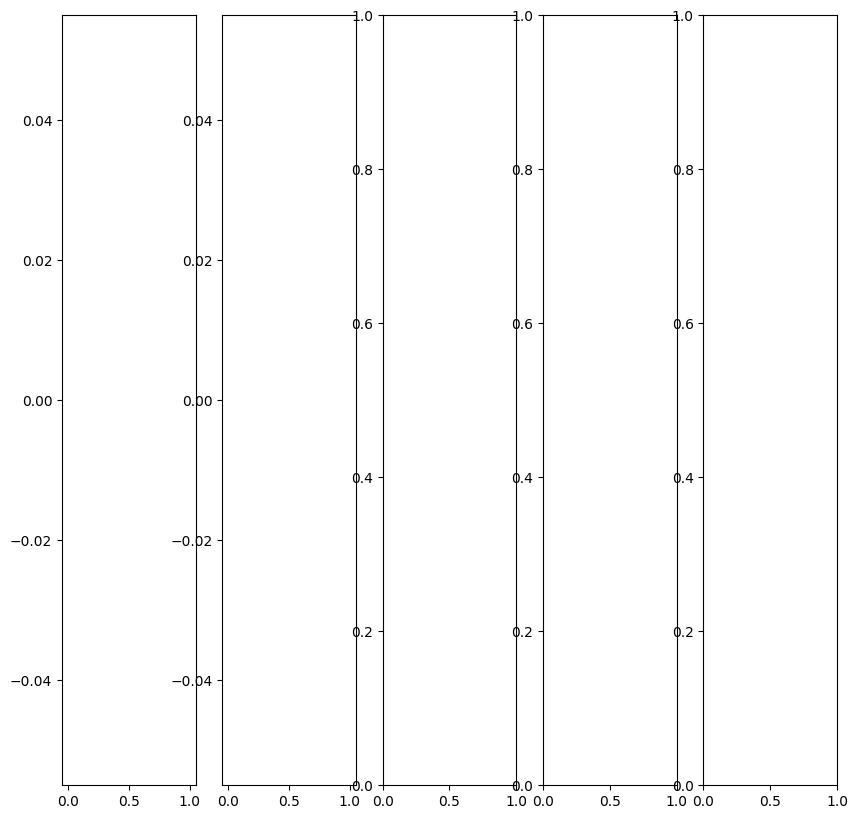

In [41]:
years = [2020,2021,2022,2023,2024]
fig, ax = plt.subplots(1,5,figsize=(10,10))
i=0
for year in years:
    subset = extract_indices_year(spindices[spindices['dt'].str.contains(str(year))],
                                                              rice_plots.copy(),
                                                              VICI_folder,
                                                              SWIA_folder)
                    
    merged_year = merge_plots_indices(rice_plots.copy(),subset,year)
    merged = merged_year[merged_year.columns.drop(f'change{year}')]
    ax[i].hist(merged['yield'])
    i+=1

118


(array([ 2.,  6.,  3.,  3.,  4., 10., 13., 14., 48., 15.]),
 array([-8.76133633, -7.7659893 , -6.7706418 , -5.77529478, -4.77994776,
        -3.78460026, -2.78925323, -1.79390597, -0.79855883,  0.19678839,
         1.19213557]),
 <BarContainer object of 10 artists>)

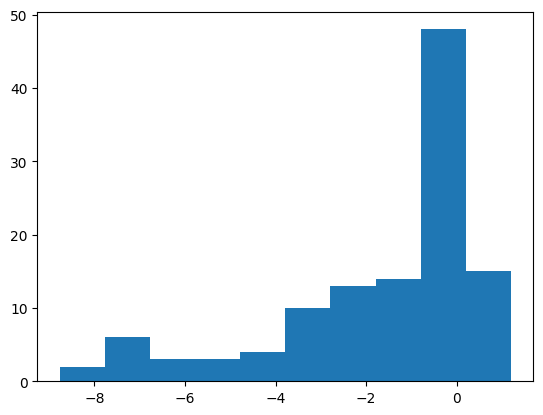

In [62]:
year = 2024
yields = pd.DataFrame(rice_plots[f'change{year}'])
yields = yields[yields[f'change{year}'].between(yields[f'change{year}'].quantile(0.1),yields[f'change{year}'].quantile(0.9))]
print(len(yields))
plt.hist(yields)


In [20]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
in_cols = [col for col in merged.columns[1:] if 'yield' not in col]
in_cols = [col for col in in_cols if 'SOIL' not in col]
in_cols = [col for col in in_cols if 'RICE' not in col]
test_vif = merged[in_cols]
vif_data = pd.DataFrame()
vif_data['feature'] = in_cols
vif_data['VIF'] = [variance_inflation_factor(test_vif.values, i)
                          for i in range(len(test_vif.columns))]
vif_data

/home/eoafrica/.conda/envs/MOFODRONI/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
/home/eoafrica/.conda/envs/MOFODRONI/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


,feature,VIF
0,SPI1_max,7.852211e+02
1,SPI3_max,9.256985e+02
2,SPI6_max,1.156847e+04
3,SPI12_max,7.774898e+02
4,SPEI1_max,6.716953e+02
5,SPEI3_max,9.282184e+02
6,SPEI6_max,1.203892e+04
7,SPEI12_max,4.899491e+03
8,VICI_max,inf
9,SWIA_max,1.633303e+03
